# Visualize results

In [1]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Define selected models to feature in charts (using original model names, not truncated)
selected_models = [
    "ministral-3b-latest",
    "ministral-8b-latest",
    "mistral-small-latest",
    "mistral-medium-latest",
    "ft:classifier:ministral-3b-latest:1945b10d:20250711:ds1:2bb5027d",
]

# Options to control which prompt types to show
show_cot = True
show_fewshot = False

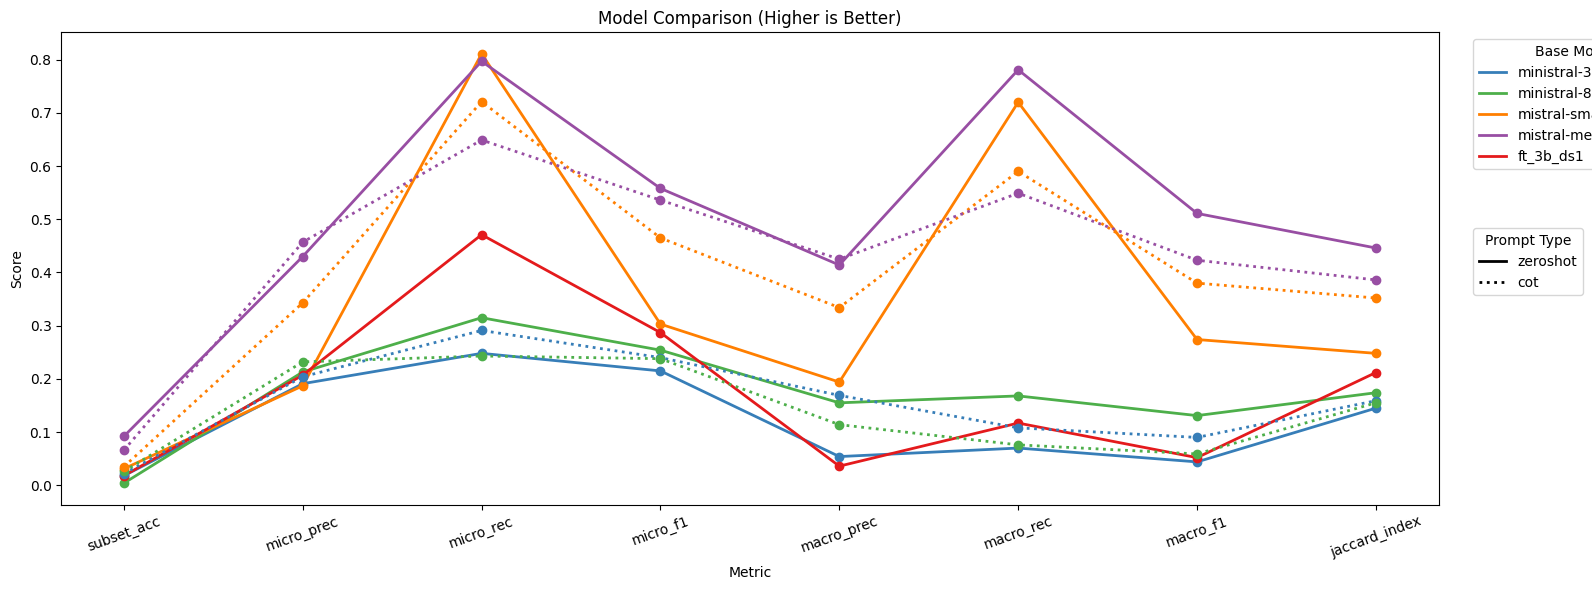

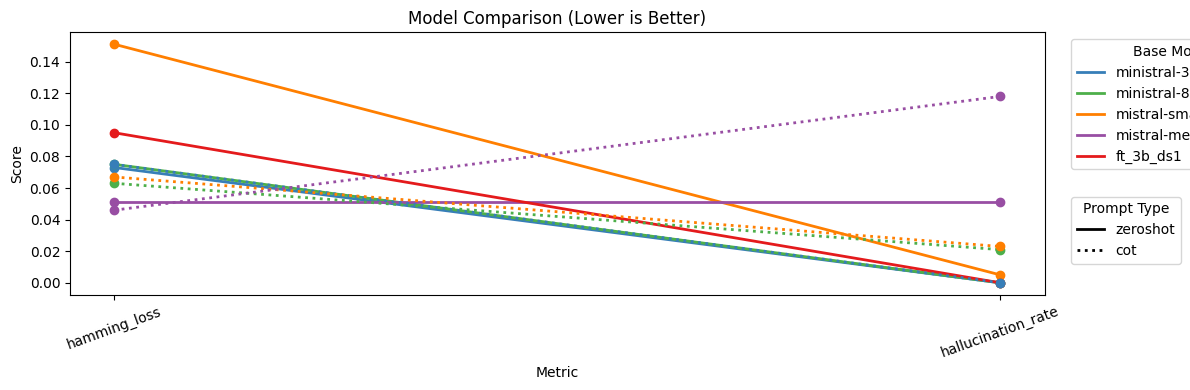

In [2]:
df = pd.read_csv("metrics.csv")

# Create display model names based on results_file column
def create_display_model_name(row):
    model_name = row["model"]
    results_file = row["results_file"].lower()
    # Shorten fine-tuned model name
    if model_name == "ft:classifier:ministral-3b-latest:1945b10d:20250711:ds1:2bb5027d":
        model_name = "ft_3b_ds1"    
    # Check for special prompt types and add suffix
    if "cot" in results_file and "fewshot" in results_file:
        return f"{model_name}_fewshot_cot"
    elif "cot" in results_file:
        return f"{model_name}_cot"
    elif "fewshot" in results_file:
        return f"{model_name}_fewshot"
    else:
        return model_name

# Apply the function to create display names
df["display_model"] = df.apply(create_display_model_name, axis=1)

# Function to get base model name and prompt type
def get_base_model_and_prompt_type(display_model):
    if "_fewshot_cot" in display_model:
        return display_model.replace("_fewshot_cot", ""), "fewshot_cot"
    elif "_cot" in display_model:
        return display_model.replace("_cot", ""), "cot"
    elif "_fewshot" in display_model:
        return display_model.replace("_fewshot", ""), "fewshot"
    else:
        return display_model, "zeroshot"

# Create base model and prompt type columns
df[["base_model", "prompt_type"]] = df["display_model"].apply(
    lambda x: pd.Series(get_base_model_and_prompt_type(x))
)

# Filter dataframe to only include selected models
df_selected = df[df["model"].isin(selected_models)]

# Filter by prompt types based on show_cot and show_fewshot options
prompt_types_to_show = ["zeroshot"]
if show_cot:
    prompt_types_to_show.extend(["cot", "fewshot_cot"])
if show_fewshot:
    prompt_types_to_show.extend(["fewshot", "fewshot_cot"])

# Remove duplicates
prompt_types_to_show = list(set(prompt_types_to_show))

# Apply prompt type filter
df_selected = df_selected[df_selected["prompt_type"].isin(prompt_types_to_show)]

# Define line styles for different prompt types
line_styles = {
    "zeroshot": "-",      # solid
    "fewshot": "--",      # dashed
    "cot": ":",           # dotted
    "fewshot_cot": "-."   # dash-dot
}

# Get unique base models for color assignment (from full dataset to maintain consistency)
unique_base_models = sorted(df["base_model"].unique())
colors = plt.cm.Set1(range(len(unique_base_models)))
color_map = dict(zip(unique_base_models, colors))

# Create legend elements (used for both charts)
selected_base_models = df_selected["base_model"].unique()
shown_prompt_types = df_selected["prompt_type"].unique()

model_legend_elements = [Line2D([0], [0], color=color_map[model], lw=2, label=model) 
                        for model in selected_base_models]
prompt_legend_elements = [Line2D([0], [0], color='black', linestyle=line_styles[prompt_type], 
                                lw=2, label=prompt_type) 
                         for prompt_type in shown_prompt_types]

# Metrics where higher is better
higher_better_metrics = [
    "subset_acc",
    "micro_prec",
    "micro_rec",
    "micro_f1",
    "macro_prec",
    "macro_rec",
    "macro_f1",
    "jaccard_index",
]

# Chart 1: Higher is better
fig, ax = plt.subplots(figsize=(16, 6))
for _, row in df_selected.iterrows():
    display_model = row["display_model"]
    base_model = row["base_model"]
    prompt_type = row["prompt_type"]
    
    ax.plot(
        higher_better_metrics,
        row[higher_better_metrics].values,
        marker="o",
        color=color_map[base_model],
        linestyle=line_styles[prompt_type],
        linewidth=2
    )

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Model Comparison (Higher is Better)")
ax.tick_params(axis='x', rotation=20)

# Add legends
model_legend = ax.legend(handles=model_legend_elements, title="Base Model", 
                        loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)
prompt_legend = ax.legend(handles=prompt_legend_elements, title="Prompt Type", 
                         loc='upper left', bbox_to_anchor=(1.02, 0.6), frameon=True)
ax.add_artist(model_legend)

plt.tight_layout()
plt.show()

# Chart 2: Plot hamming_loss and hallucination_rate (lower is better)
fig, ax = plt.subplots(figsize=(12, 4))
for _, row in df_selected.iterrows():
    ax.plot(
        ["hamming_loss", "hallucination_rate"],
        row[["hamming_loss", "hallucination_rate"]].values,
        marker="o",
        color=color_map[row["base_model"]],
        linestyle=line_styles[row["prompt_type"]],
        linewidth=2
    )

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Model Comparison (Lower is Better)")
ax.tick_params(axis='x', rotation=20)

# Add legends (reuse the same legend elements)
model_legend = ax.legend(handles=model_legend_elements, title="Base Model", 
                        loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)
prompt_legend = ax.legend(handles=prompt_legend_elements, title="Prompt Type", 
                         loc='upper left', bbox_to_anchor=(1.02, 0.4), frameon=True)
ax.add_artist(model_legend)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

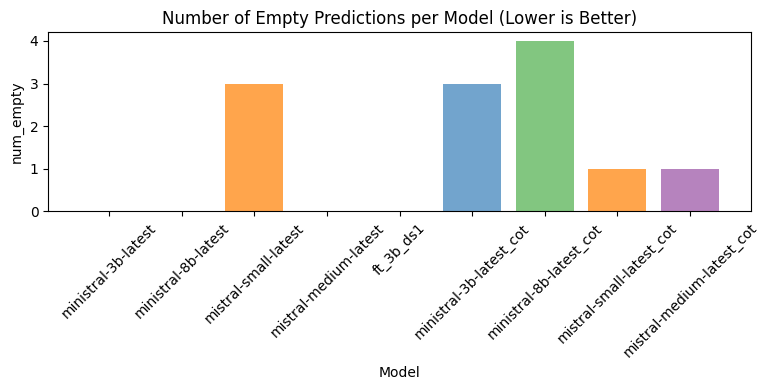

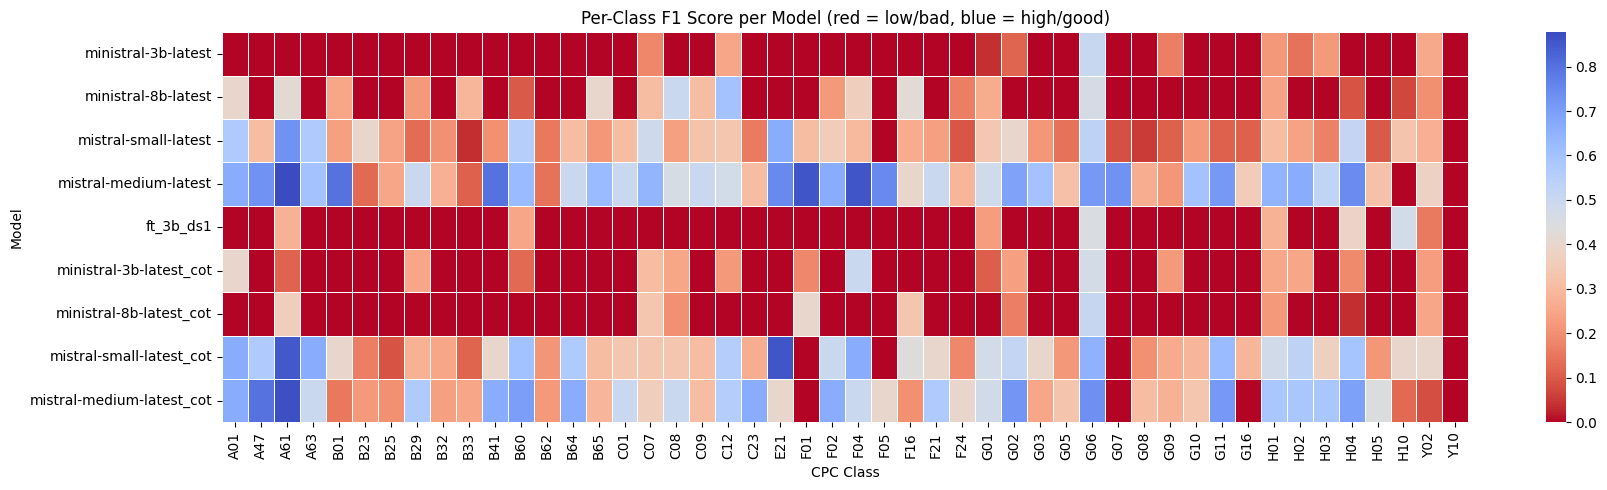

In [3]:
# Create model color legend (top right) - only for selected models
selected_base_models = df_selected["base_model"].unique()
model_legend_elements = [Line2D([0], [0], color=color_map[model], lw=2, label=model) 
                        for model in selected_base_models]
model_legend = ax.legend(handles=model_legend_elements, title="Base Model", 
                        loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)

# Create prompt type legend (below model legend)
prompt_legend_elements = [Line2D([0], [0], color='black', linestyle=line_styles[prompt_type], 
                                lw=2, label=prompt_type) 
                         for prompt_type in line_styles.keys()]
prompt_legend = ax.legend(handles=prompt_legend_elements, title="Prompt Type", 
                         loc='upper left', bbox_to_anchor=(1.02, 0.4), frameon=True)

# Add both legends to the plot
ax.add_artist(model_legend)

plt.tight_layout()
plt.show()

# Chart 3: Plot num_empty separately
plt.figure(figsize=(8, 4))
for _, row in df_selected.iterrows():
    display_model = row["display_model"]
    base_model = row["base_model"]
    
    plt.bar(display_model, row["num_empty"], color=color_map[base_model], alpha=0.7)
plt.xlabel("Model")
plt.ylabel("num_empty")
plt.title("Number of Empty Predictions per Model (Lower is Better)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 4: Per-class F1 score
class_f1_matrix = pd.DataFrame(
    [ast.literal_eval(row["class_f1"]) for _, row in df_selected.iterrows()], index=df_selected["display_model"]
)

plt.figure(figsize=(18, 5))
sns.heatmap(
    class_f1_matrix.astype(float),
    cmap="coolwarm_r",  # The "_r" reverses the colormap
    annot=False,
    linewidths=0.5,
)
plt.title("Per-Class F1 Score per Model (red = low/bad, blue = high/good)")
plt.xlabel("CPC Class")
plt.ylabel("Model")
plt.tight_layout()
plt.show()